In [18]:
import time
from jimgw.jim import Jim
from jimgw.detector import H1, L1
from jimgw.likelihood import HeterodynedTransientLikelihoodFD, TransientLikelihoodFD
from jimgw.waveform import RippleIMRPhenomD
from jimgw.waveform import RippleTaylorF2
from jimgw.prior import Uniform
import jax.numpy as jnp
import jax

jax.config.update("jax_enable_x64", True)

import numpy as np
import matplotlib.pyplot as plt

In [19]:
import jaxlib
jax.devices()

[cuda(id=0)]

# Fetch data

Fetch the real data

In [20]:
total_time_start = time.time()

# Fetch a T second segment centered on a GW event (e.g. GW150914 or GW170817)
gps_150914 = 1126259462.4
gps_170817 = 1187008882.43

gps = gps_170817

T = 4
start = gps - T/2
end = gps + T/2
fmin = 20.0
fmax = 1024.0

ifos = ["H1", "L1"]

H1.load_data(gps, T/2, T/2, fmin, fmax, psd_pad=16, tukey_alpha=0.2)
L1.load_data(gps, T/2, T/2, fmin, fmax, psd_pad=16, tukey_alpha=0.2)

Fetching data from H1...
Fetching PSD data...
Finished generating data.
Fetching data from L1...
Fetching PSD data...
Finished generating data.


Get priors and likelihood ready

In [21]:
prior_imr = Uniform(
    xmin=[10, 0.125, -1.0, -1.0, 0.0, -0.05, 0.0, -1, 0.0, 0.0, -1.0],
    xmax=[80.0, 1.0, 1.0, 1.0, 2000.0, 0.05, 2 * jnp.pi, 1.0, jnp.pi, 2 * jnp.pi, 1.0],
    naming=[
        "M_c",
        "q",
        "s1_z",
        "s2_z",
        "d_L",
        "t_c",
        "phase_c",
        "cos_iota",
        "psi",
        "ra",
        "sin_dec",
    ],
    transforms = {"q": ("eta", lambda params: params['q']/(1+params['q'])**2),
                 "cos_iota": ("iota",lambda params: jnp.arccos(jnp.arcsin(jnp.sin(params['cos_iota']/2*jnp.pi))*2/jnp.pi)),
                 "sin_dec": ("dec",lambda params: jnp.arcsin(jnp.arcsin(jnp.sin(params['sin_dec']/2*jnp.pi))*2/jnp.pi))} # sin and arcsin are periodize cos_iota and sin_dec
)


prior_taylorf2 = Uniform(
    xmin=[10, 0.125, -1.0, -1.0, 0.0, 0.0, 0.0, -0.05, 0.0, -1, 0.0, 0.0, -1.0],
    xmax=[80.0, 1.0, 1.0, 1.0, 5000.0, 5000.0, 2000.0, 0.05, 2 * jnp.pi, 1.0, jnp.pi, 2 * jnp.pi, 1.0],
    naming=[
        "M_c",
        "q",
        "s1_z",
        "s2_z",
        "lambda1",
        "lambda2",
        "d_L",
        "t_c",
        "phase_c",
        "cos_iota",
        "psi",
        "ra",
        "sin_dec",
    ],
    transforms = {"q": ("eta", lambda params: params['q']/(1+params['q'])**2),
                 "cos_iota": ("iota",lambda params: jnp.arccos(jnp.arcsin(jnp.sin(params['cos_iota']/2*jnp.pi))*2/jnp.pi)),
                 "sin_dec": ("dec",lambda params: jnp.arcsin(jnp.arcsin(jnp.sin(params['sin_dec']/2*jnp.pi))*2/jnp.pi))} # sin and arcsin are periodize cos_iota and sin_dec
)

which = "RippleIMRPhenomD"

if which == "RippleTaylorF2":
    prior = prior_taylorf2
    mass_matrix = jnp.eye(13) # 13 if lambdas are specified for the tidal waveforms
    likelihood = TransientLikelihoodFD([H1, L1], waveform=RippleTaylorF2(), trigger_time=gps, duration=4, post_trigger_duration=2)
elif which == "RippleIMRPhenomD":
    prior = prior_imr
    mass_matrix = jnp.eye(11)
    likelihood = TransientLikelihoodFD([H1, L1], waveform=RippleIMRPhenomD(), trigger_time=gps, duration=4, post_trigger_duration=2)
else:
    print("Waveform model not recognized")
# likelihood = HeterodynedTransientLikelihoodFD([H1, L1], prior=prior, bounds=[prior.xmin, prior.xmax], waveform=RippleIMRPhenomD(), trigger_time=gps, duration=4, post_trigger_duration=2)

In [22]:
mass_matrix = mass_matrix.at[1, 1].set(1e-3)
mass_matrix = mass_matrix.at[5, 5].set(1e-3)
local_sampler_arg = {"step_size": mass_matrix * 3e-3}


### Override the default parameters from Jim if desired (see keyword arguments below)
### Note: this seems to increase the time it takes to run the cells below!

jim = Jim(
    likelihood,
    prior,
    n_loop_training=200,
    n_loop_production=10,
    n_local_steps=300,
    n_global_steps=300,
    n_chains=500,
    n_epochs=300,
    learning_rate=0.001,
    max_samples = 60000,
    momentum=0.9,
    batch_size=30000,
    use_global=True,
    keep_quantile=0.,
    train_thinning=1,
    output_thinning=30,
    local_sampler_arg=local_sampler_arg,
    num_layers = 6,
    hidden_size = [32,32],
    num_bins = 8
)

jim.maximize_likelihood([prior.xmin, prior.xmax])
# initial_guess = jnp.array(jnp.load('initial.npz')['chain'])
jim.sample(jax.random.PRNGKey(42))


jit is requested, precompiling kernels and update...
Compiling MALA body


TypeError: dot_general requires contracting dimensions to have the same shape, got (13,) and (11,).

**Computationally demanding step:**

In [ ]:
jim.sample(jax.random.PRNGKey(42))

No autotune found, use input sampler_params
Training normalizing flow


Tuning global sampler:   0%|          | 0/3 [00:00<?, ?it/s]

Compiling MALA body


Tuning global sampler: 100%|██████████| 3/3 [03:58<00:00, 79.51s/it] 


Starting Production run


Production run: 100%|██████████| 3/3 [00:00<00:00,  5.24it/s]


In [ ]:
jim.print_summary()

Training summary
M_c: 40.941 +/- 17.177
q: 0.446 +/- 0.208
s1_z: 0.077 +/- 0.499
s2_z: 0.101 +/- 0.473
lambda1: 2887.921 +/- 1379.733
lambda2: 2538.470 +/- 1338.510
d_L: 1006.685 +/- 614.021
t_c: 0.005 +/- 0.026
phase_c: 2.355 +/- 1.500
cos_iota: -0.265 +/- 0.574
psi: 1.449 +/- 0.897
ra: 3.162 +/- 1.733
sin_dec: 0.022 +/- 0.429
Log probability: -3274.175 +/- 21035.426
Local acceptance: 0.003 +/- 0.052
Global acceptance: 0.024 +/- 0.152
Max loss: 502.836, Min loss: 7.405
Production summary
M_c: 42.553 +/- 10.807
q: 0.410 +/- 0.180
s1_z: 0.096 +/- 0.408
s2_z: 0.081 +/- 0.279
lambda1: 2923.897 +/- 771.494
lambda2: 2403.147 +/- 1020.999
d_L: 629.901 +/- 425.360
t_c: 0.002 +/- 0.016
phase_c: 1.630 +/- 0.997
cos_iota: -0.596 +/- 0.359
psi: 1.259 +/- 0.702
ra: 2.773 +/- 1.331
sin_dec: 0.040 +/- 0.323
Log probability: 1498.503 +/- 850.909
Local acceptance: 0.000 +/- 0.000
Global acceptance: 0.007 +/- 0.086


In [ ]:
# jim.get_samples()
for key in jim.__dict__:
    print(key)
    
for key in jim.Sampler.__dict__:
    print(key)

Likelihood
Prior
Sampler
rng_keys_nf
rng_keys_mcmc
n_dim
n_loop_training
n_loop_production
n_local_steps
n_global_steps
n_chains
n_epochs
learning_rate
max_samples
momentum
batch_size
use_global
logging
keep_quantile
local_autotune
train_thinning
output_thinning
n_sample_max
verbose
variables
local_sampler
global_sampler
likelihood_vec
optim_state
nf_training_loop
summary


In [ ]:
# Set params for only production
jim.Sampler.n_loop_training = 0
jim.Sampler.n_loop_production = 100

jim.sample(jax.random.PRNGKey(41))

No autotune found, use input sampler_params
Training normalizing flow


Tuning global sampler: 0it [00:00, ?it/s]


Starting Production run


Production run:   0%|          | 0/100 [00:00<?, ?it/s]

Production run: 100%|██████████| 100/100 [00:54<00:00,  1.83it/s]


In [ ]:
jim.print_summary()

Training summary
M_c: 40.941 +/- 17.177
q: 0.446 +/- 0.208
s1_z: 0.077 +/- 0.499
s2_z: 0.101 +/- 0.473
lambda1: 2887.921 +/- 1379.733
lambda2: 2538.470 +/- 1338.510
d_L: 1006.685 +/- 614.021
t_c: 0.005 +/- 0.026
phase_c: 2.355 +/- 1.500
cos_iota: -0.265 +/- 0.574
psi: 1.449 +/- 0.897
ra: 3.162 +/- 1.733
sin_dec: 0.022 +/- 0.429
Log probability: -3274.175 +/- 21035.426
Local acceptance: 0.003 +/- 0.052
Global acceptance: 0.024 +/- 0.152
Max loss: 502.836, Min loss: 7.405
Production summary
M_c: 42.804 +/- 9.505
q: 0.411 +/- 0.157
s1_z: 0.193 +/- 0.312
s2_z: 0.106 +/- 0.225
lambda1: 3327.223 +/- 903.375
lambda2: 2301.389 +/- 1115.192
d_L: 473.126 +/- 240.610
t_c: -0.000 +/- 0.019
phase_c: 1.198 +/- 0.628
cos_iota: -0.725 +/- 0.196
psi: 0.941 +/- 0.561
ra: 1.768 +/- 0.968
sin_dec: -0.001 +/- 0.286
Log probability: 2612.114 +/- 1051.514
Local acceptance: 0.000 +/- 0.000
Global acceptance: 0.002 +/- 0.042


In [ ]:
samples = jim.get_samples()
print(np.shape(samples["M_c"]))

(20, 10300)


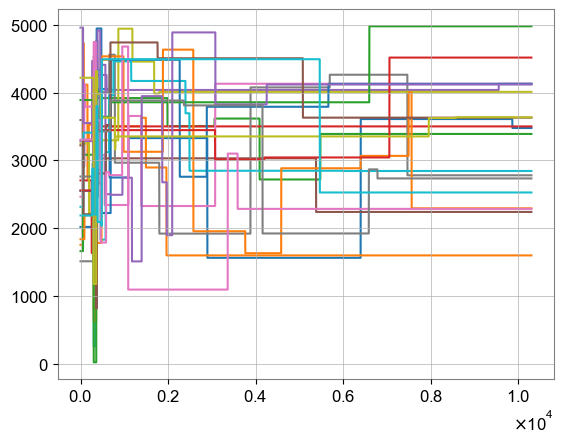

In [ ]:
for i in range(np.shape(samples["M_c"])[0]):
    plt.plot(samples["lambda1"][i])
plt.show()

In [ ]:
test = samples["lambda1"][0]
test

Array([2017.61855442, 2017.61855442, 2017.61855442, ...,
       3478.0549568 , 3478.0549568 , 3478.0549568 ],      dtype=float64)